In [ ]:
# sample_window = [10,15,17,19,21,23,25]
# sample_window_std = []   
# window_std_variances = {}

# for w in sample_window:
#     stds = []
    
#     for i in range(0, len(pressure) - w, w):
#         arr1 = pressure[i:i+w]
#         stds.append(np.std(arr1))     
#         window_std_variances[w] = np.var(stds)


# best_window = min(window_std_variances, key=window_std_variances.get)

# print("best window ", best_window)





best window  10


# 1.2mM

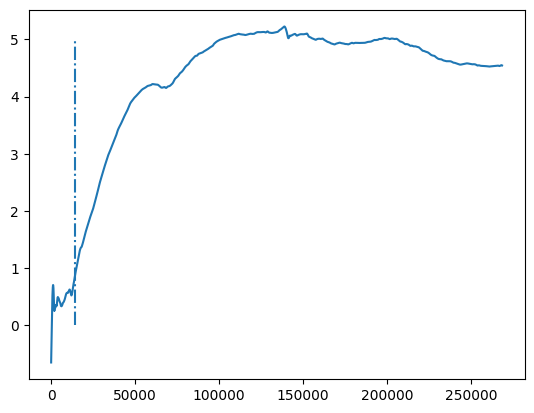

cropping at  14092


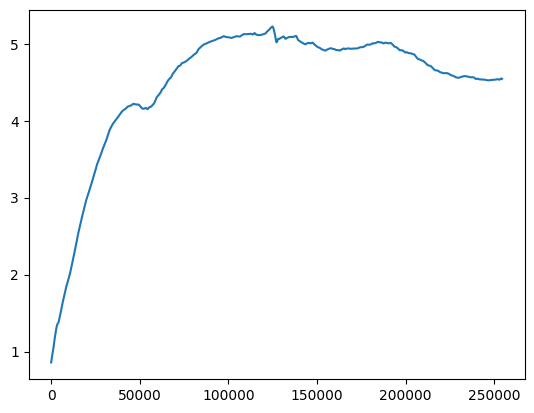

0.20050787744360532


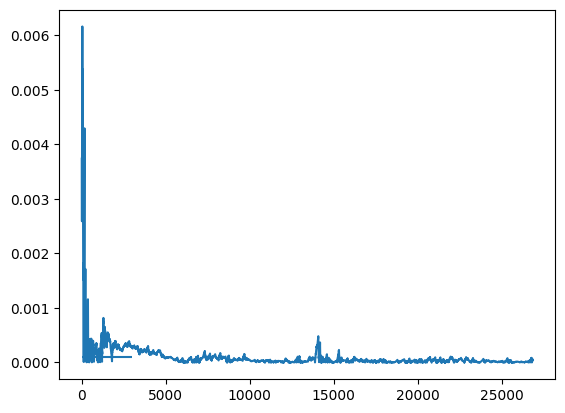

In [ ]:
df = pd.read_csv( r"C:\Users\chand\Documents\GitHub\Thesis\M3_1.2mM_37deg_pressure_o2_release.csv")
time = df["Time (h)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 10 #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

# 2.18mM

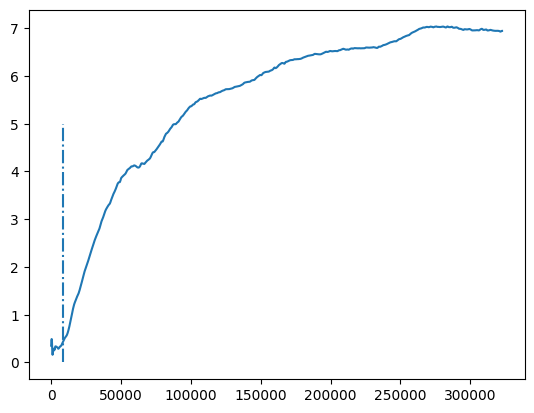

cropping at  8163


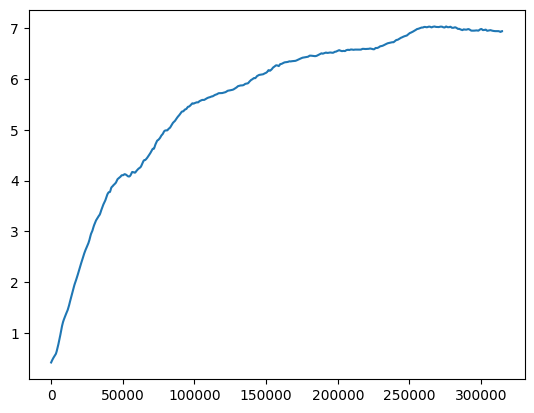

0.06186360789322051


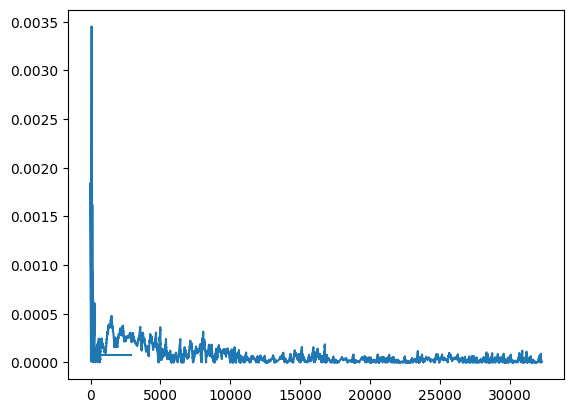

In [94]:
df = pd.read_csv( r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv")
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 10 #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_23164\3024702985.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv",


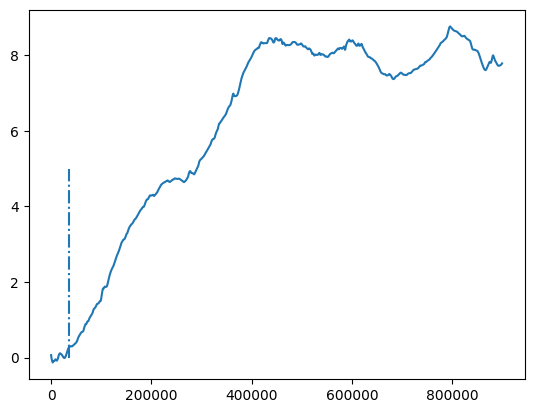

cropping at  35512


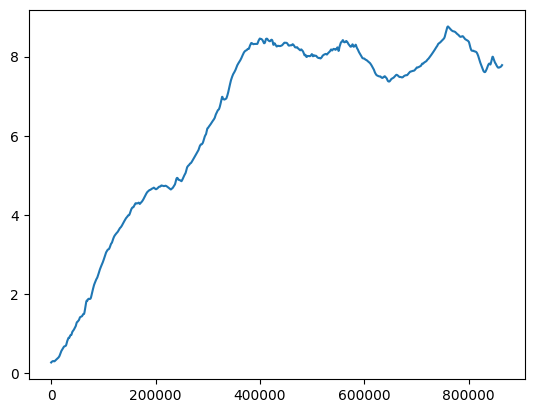

0.0967280971662828


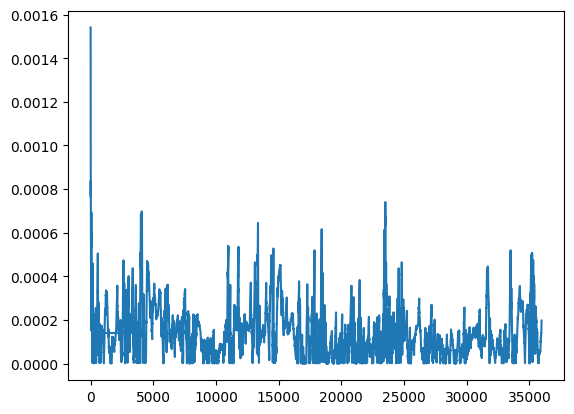

In [102]:
# Or try:
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv", 
                 on_bad_lines='skip')
time = df["Time (s)"]
pressure = df["DWT denoised pressure (kPa)"]
time = time.values[:]
pressure = pressure.values[:]
window = 25  #no of samples
# std_all = np.std(pressure)
std_all=[]
for i in range(0,len(pressure)-window,window):
    arr1 = pressure[i:i+window]
    # print(np.std(arr1))
    std_all.append(np.std(arr1))
    # if np.std(arr1)>std_all:
    #     crop_idx = i
mean_std = np.mean(std_all)
thres = mean_std+np.std(std_all)
for i in std_all:
    if i>thres:
        cut_idx = i
for i in range(0,len(std_all)):
    if std_all[i]==cut_idx:
        crop_idx = i
        
        
        
plt.plot(pressure)
plt.vlines(crop_idx,0,5,linestyles="dashdot")
plt.show()
weed = pressure[:crop_idx]
pressure = pressure[crop_idx:]
# time = time[crop_idx:]
print("cropping at ", crop_idx)
plt.plot(pressure)
plt.show()
# print("weed vs np.mean", np.std(weed),mean_std )
print(np.abs(np.std(weed)-mean_std))
plt.plot(std_all)
plt.hlines(mean_std,0,3000)
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_23164\419932475.py:31: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv",


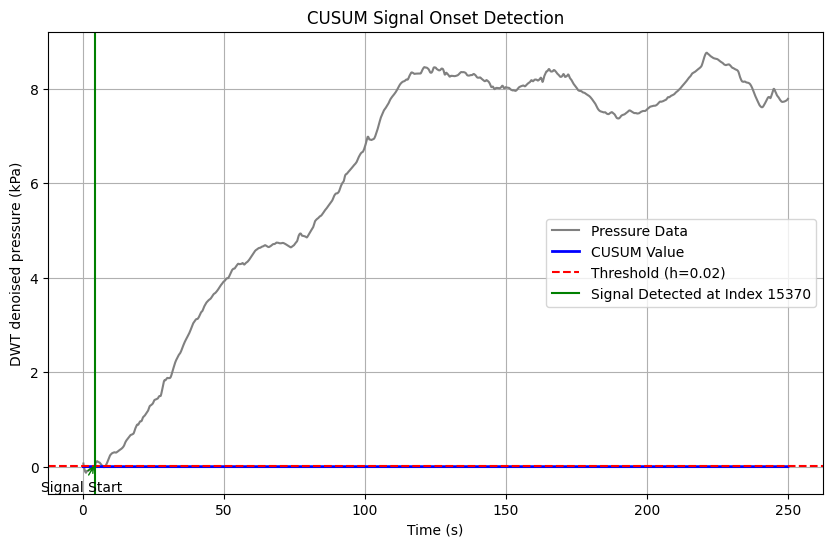

Signal detected at index: 15370
Signal detected at time: 4.44 seconds


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def cusum(data, threshold, drift):
    """
    Finds the first index where the CUSUM value exceeds the threshold.
    
    Args:
        data (np.array): The input sensor data.
        threshold (float): The detection threshold (h).
        drift (float): The drift or slack value (k).
        
    Returns:
        int: The index where the signal is detected, or -1 if no signal is found.
        np.array: The cumulative sum series.
    """
    cusum_series = np.zeros(len(data))
    for t in range(1, len(data)):
        # Calculate the deviation and update the cumulative sum
        deviation = data[t] - data[0] - drift
        cusum_series[t] = max(0, cusum_series[t-1] + deviation)

        # Check if the CUSUM exceeds the threshold
        if cusum_series[t] > threshold:
            return t, cusum_series
            
    return -1, cusum_series

# 1. Load data from the CSV file
df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M1-2.5mM\data files\M1_2.5mM_pressure_RT_o2_release.csv",
                 on_bad_lines='skip')
time = df["Time (s)"].values[:]
pressure = df["DWT denoised pressure (kPa)"].values[:]

# 2. Set the CUSUM parameters
# The baseline is a section of your data that you know is only noise.
# Assuming the first 50 data points are the noise baseline. Adjust as needed.
baseline_data = pressure[:50]
baseline_mean = np.mean(baseline_data)
baseline_std = np.std(baseline_data)

# Using rule-of-thumb for h and k
h = 7 * baseline_std  # Threshold
k = 0.5 * baseline_std  # Drift (slack)

# 3. Apply the CUSUM algorithm
detection_index, cusum_series = cusum(pressure, h, k)

# 4. Plot the results to visualize the detection
plt.figure(figsize=(10, 6))
plt.plot(time, pressure, label='Pressure Data', color='gray')
plt.plot(time, cusum_series, label='CUSUM Value', color='blue', linewidth=2)
plt.axhline(h, color='red', linestyle='--', label=f'Threshold (h={h:.2f})')

if detection_index != -1:
    plt.axvline(time[detection_index], color='green', linestyle='-', label=f'Signal Detected at Index {detection_index}')
    plt.annotate('Signal Start', (time[detection_index], pressure[detection_index]),
                 textcoords="offset points", xytext=(-10,-20), ha='center',
                 arrowprops=dict(arrowstyle="->", color='green'))

plt.title('CUSUM Signal Onset Detection')
plt.xlabel('Time (s)')
plt.ylabel('DWT denoised pressure (kPa)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Signal detected at index: {detection_index}")
print(f"Signal detected at time: {time[detection_index]:.2f} seconds")

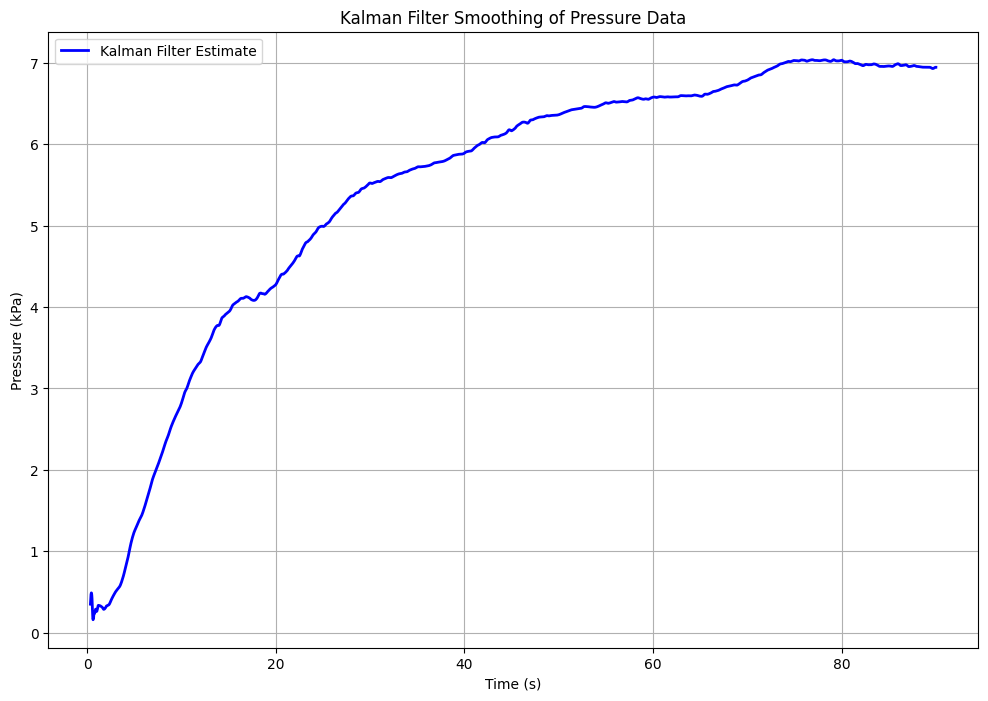

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

# --- 1. Load your data from the CSV file ---
# Make sure to replace the file path with your actual path.

df = pd.read_csv(r"C:\Users\chand\Documents\GitHub\Thesis\M2-2.18mM\37 C\data files\Version 1\M2_2.18mM_37deg_pressure_o2_release.csv")
time = df["Time (s)"].values
pressure = df["DWT denoised pressure (kPa)"].values


# --- 2. Define the Kalman Filter ---
# We'll use a 2D state: [position, velocity].
# Our sensor only measures position, so the measurement is 1D.
kf = KalmanFilter(dim_x=2, dim_z=1)

# --- 3. Define the State-Space Matrices ---

# State transition matrix (F):
# Describes how the state changes from one time step to the next.
dt = 1 # We'll assume a constant time step of 1s between readings.
kf.F = np.array([[1., dt],
                 [0., 1.]])

# Measurement function (H):
# Describes how the sensor measurements relate to the state.
kf.H = np.array([[1., 0.]])

# Process noise covariance (Q):
# Represents the uncertainty in our model (e.g., small random changes in velocity).
# Tune this value: a lower Q trusts our trend model more.
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.05)

# Measurement noise covariance (R):
# Represents the noise from the sensor.
# You will need to tune this value based on your data's noise level.
# Start with a moderate value and adjust it.
kf.R = np.array([[1.0]]) 

# --- 4. Initialize the State and Uncertainty ---
# The initial position can be the first data point.
# The initial velocity (trend) can be estimated from the first few points.
# We'll set it to 0 initially and let the filter learn the trend.
kf.x = np.array([[pressure[0]],
                 [0.]])

# Initial uncertainty covariance (P): A large value indicates high initial uncertainty.
kf.P *= 1000.0

# --- 5. Run the Kalman Filter on your data ---
estimated_values = []

# Loop through your pressure data
for z in pressure:
    kf.predict()
    kf.update(np.array([[z]]))
    estimated_values.append(kf.x[0, 0])

# --- 6. Visualize the Results ---
plt.figure(figsize=(12, 8))
# plt.plot(time, pressure, 'r+', label='Denoised Pressure Data (DWT)')
plt.plot(time, estimated_values, 'b-', label='Kalman Filter Estimate', linewidth=2)
plt.title('Kalman Filter Smoothing of Pressure Data')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)
plt.show()